In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# I will point these to the CRU files I already saved earlier
cru_temp_files = {
    "Ethiopia": "Ethiopia_CRU_temp_1901_2024.csv",
    "Kenya": "Kenya_CRU_temp_1901_2024.csv",
    "Tanzania": "Tanzania_CRU_temp_1901_2024.csv",
    "Uganda": "Uganda_CRU_temp_1901_2024.csv",
}

# later notebooks will use the KR files, but here I only need the list of survey years
kr_clean_files = [
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Ethiopia_KR_2016_clean.csv",
    "Kenya_KR_2008_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]

# small helper to deal with slightly different year column names across KR files
def pick_col(cols, options):
    for c in options:
        if c in cols:
            return c
    return None


In [5]:
climate_list = []

for country in cru_temp_files:
    fname = cru_temp_files[country]
    print("working on", country, "file:", fname)
    
    df = pd.read_csv(fname)
    
    # just keep year and annual temp so the table is smaller
    temp = df[["YEAR", "ANN"]].copy()
    temp["country"] = country
    
    # rename so it is easier to type later
    temp = temp.rename(columns={
        "YEAR": "year",
        "ANN": "temp_ann"
    })
    
    # baseline temp from 1981 to 2010
    base = temp[(temp["year"] >= 1981) & (temp["year"] <= 2010)]
    base_mean = base["temp_ann"].mean()
    
    # anomaly compared to that baseline
    temp["temp_anom"] = temp["temp_ann"] - base_mean
    
    climate_list.append(temp)

climate_all = pd.concat(climate_list)
climate_all.head()


working on Ethiopia file: Ethiopia_CRU_temp_1901_2024.csv
working on Kenya file: Kenya_CRU_temp_1901_2024.csv
working on Tanzania file: Tanzania_CRU_temp_1901_2024.csv
working on Uganda file: Uganda_CRU_temp_1901_2024.csv


,year,temp_ann,country,temp_anom
0,1901,22.7,Ethiopia,-0.256667
1,1902,22.6,Ethiopia,-0.356667
2,1903,22.7,Ethiopia,-0.256667
3,1904,22.5,Ethiopia,-0.456667
4,1905,22.6,Ethiopia,-0.356667


In [7]:
# list of KR child files I cleaned already
kr_clean_files = [
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]


In [9]:
survey_years_list = []

for fname in kr_clean_files:
    print("checking survey year for", fname)
    
    # I just read a few rows to see the columns and the year value
    df = pd.read_csv(fname, nrows=50)
    cols = df.columns.tolist()
    
    # my year column shows up with slightly different labels in some files
    year_col = pick_col(cols, ["interview year", "year_interview", "v007"])
    if year_col is None:
        print("  could not find year column here, skipping for now")
        continue
    
    country = fname.split("_")[0]
    
    # I assume one main year per file
    year_vals = df[year_col].dropna().unique()
    survey_year = int(year_vals[0])
    
    survey_years_list.append({
        "country": country,
        "survey_year": survey_year
    })

survey_years = pd.DataFrame(survey_years_list).drop_duplicates()
survey_years.sort_values(["country", "survey_year"])


checking survey year for Ethiopia_KR_2008_clean.csv
checking survey year for Ethiopia_KR_2011_clean.csv
checking survey year for Kenya_KR_2003_clean.csv
checking survey year for Kenya_KR_2009_clean.csv
checking survey year for Kenya_KR_2014_clean.csv
checking survey year for Kenya_KR_2022_clean.csv
checking survey year for Tanzania_KR_2010_clean.csv
checking survey year for Tanzania_KR_2015_clean.csv
checking survey year for Tanzania_KR_2022_clean.csv
checking survey year for Uganda_KR_2011_clean.csv
checking survey year for Uganda_KR_2016_clean.csv


,country,survey_year
0,Ethiopia,2008
1,Ethiopia,2011
2,Kenya,2003
3,Kenya,2009
4,Kenya,2014
5,Kenya,2022
6,Tanzania,2010
7,Tanzania,2015
8,Tanzania,2022
9,Uganda,2011


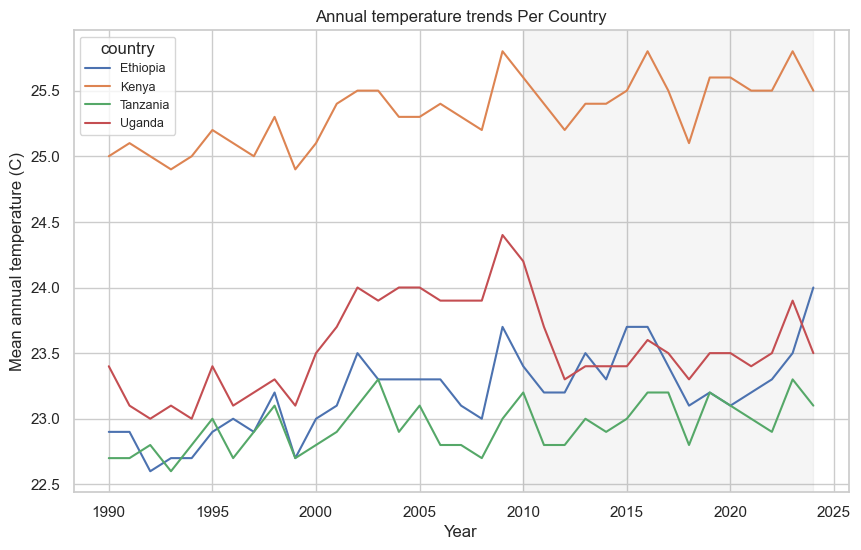

In [26]:
plt.figure(figsize=(10, 6))

# focus on 1990 onward so it is not too crowded
for country, group in climate_all.groupby("country"):
    g = group[group["year"] >= 1990]
    plt.plot(g["year"], g["temp_ann"], label=country)

# light shading for the period from 2010 onward

plt.axvspan(2010, 2024, alpha=0.08, color="gray")

plt.xlabel("Year")
plt.ylabel("Mean annual temperature (C)")
plt.title("Annual temperature trends Per Country")
plt.legend(title="country", fontsize=9)
plt.show()
